# Лабораторная работа №5: градиентный бустинг

Автор: Гроза И.В., группа 6401

Датасет: `weatherAUS.csv`  
Цель классификации: `RainTomorrow`  
Цель регрессии: `MaxTemp`


## Анализ и план

**Выбор датасета**: `weatherAUS.csv` содержит численные и категориальные признаки, поэтому подходит для обеих частей работы: классификации и регрессии.

**Порядок работы**:
1. Загрузить и кратко описать датасет.
2. Выполнить предобработку: обработать пропуски, извлечь календарные признаки из даты, удалить поля с большим числом пропусков.
3. Решить задачу классификации `RainTomorrow` с помощью `AdaBoost`, `GradientBoostingClassifier`, `XGBoost` и `CatBoost`, сравнить метрики и выбрать лучшую модель.
4. Для лучшего классификатора выполнить `SHAP`-анализ, отфильтровать признаки, переобучить модель и сравнить качество до и после фильтрации.
5. Решить задачу регрессии `MaxTemp` с помощью `XGBRegressor` и `CatBoostRegressor`, затем повторить фильтрацию признаков по важности и сравнить качество.

**Что учитывается при обучении**:
- В `RainTomorrow` есть дисбаланс классов, поэтому для обучения используется взвешивание объектов через `sample_weight`.
- Для `AdaBoost`, `GradientBoostingClassifier` и `XGBoost` категориальные признаки кодируются `OrdinalEncoder`, а для `CatBoost` передаются в исходном категориальном виде через `cat_features`.
- Сетки гиперпараметров оставлены небольшими, чтобы ноутбук можно было выполнить за разумное время.

## Подготовка окружения

Ниже оставлена опциональная ячейка установки зависимостей. Она нужна только если в окружении ещё нет `xgboost`, `catboost` и `shap`.


In [63]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from IPython.display import display
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier, XGBRegressor, plot_tree as xgb_plot_tree

SEED = 42
TEST_SIZE = 0.2
CLASSIFICATION_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
REGRESSION_CV = KFold(n_splits=3, shuffle=True, random_state=SEED)
FAST_MODE_ROWS = None  # Например, 40000 для ускоренной отладки. None = весь датасет.
SHAP_SAMPLE_SIZE = 600

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
pd.set_option("display.max_columns", None)
shap.initjs()


## Загрузка датасета

Источник данных: локальный файл `../data/weatherAUS.csv`.  
В работе используются метеонаблюдения по городам Австралии. Один и тот же датасет применяется для двух задач:
- классификация: прогноз `RainTomorrow`
- регрессия: прогноз `MaxTemp`


In [64]:
dataset_path = "../data/weatherAUS.csv"

raw_df = pd.read_csv(dataset_path, na_values=["NA"])
raw_df["Date"] = pd.to_datetime(raw_df["Date"])

if FAST_MODE_ROWS is not None:
    raw_df = (
        raw_df.sample(n=min(FAST_MODE_ROWS, len(raw_df)), random_state=SEED)
        .sort_values("Date")
        .reset_index(drop=True)
    )

print(f"Dataset path: {dataset_path}")
print(f"Shape: {raw_df.shape}")
display(raw_df.head())
raw_df.info()


Dataset path: ../data/weatherAUS.csv
Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[us]
 1   Location       145460 non-null  str           
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  str           
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  str           
 10  WindDir3pm     141232 non-null  str           
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  Pressure9am

## Описание признаков датасета

Ниже приведено краткое описание исходных признаков, единиц измерения и ролей. В регрессионной части `MaxTemp` используется как целевая переменная, а в классификационной части он остаётся предиктором.


In [65]:
feature_reference = [
    {"feature": "Date", "type": "date", "units": "дата", "description": "Дата наблюдения"},
    {"feature": "Location", "type": "categorical", "units": "-", "description": "Город / метеостанция"},
    {"feature": "MinTemp", "type": "numeric", "units": "°C", "description": "Минимальная температура за сутки"},
    {"feature": "MaxTemp", "type": "numeric", "units": "°C", "description": "Максимальная температура за сутки; цель регрессии"},
    {"feature": "Rainfall", "type": "numeric", "units": "мм", "description": "Суммарные осадки за сутки"},
    {"feature": "Evaporation", "type": "numeric", "units": "мм", "description": "Испарение"},
    {"feature": "Sunshine", "type": "numeric", "units": "часы", "description": "Продолжительность солнечного сияния"},
    {"feature": "WindGustDir", "type": "categorical", "units": "-", "description": "Направление порыва ветра"},
    {"feature": "WindGustSpeed", "type": "numeric", "units": "км/ч", "description": "Скорость порыва ветра"},
    {"feature": "WindDir9am", "type": "categorical", "units": "-", "description": "Направление ветра в 9 утра"},
    {"feature": "WindDir3pm", "type": "categorical", "units": "-", "description": "Направление ветра в 15:00"},
    {"feature": "WindSpeed9am", "type": "numeric", "units": "км/ч", "description": "Скорость ветра в 9 утра"},
    {"feature": "WindSpeed3pm", "type": "numeric", "units": "км/ч", "description": "Скорость ветра в 15:00"},
    {"feature": "Humidity9am", "type": "numeric", "units": "%", "description": "Влажность в 9 утра"},
    {"feature": "Humidity3pm", "type": "numeric", "units": "%", "description": "Влажность в 15:00"},
    {"feature": "Pressure9am", "type": "numeric", "units": "гПа", "description": "Давление в 9 утра"},
    {"feature": "Pressure3pm", "type": "numeric", "units": "гПа", "description": "Давление в 15:00"},
    {"feature": "Cloud9am", "type": "numeric", "units": "окты", "description": "Облачность в 9 утра"},
    {"feature": "Cloud3pm", "type": "numeric", "units": "окты", "description": "Облачность в 15:00"},
    {"feature": "Temp9am", "type": "numeric", "units": "°C", "description": "Температура в 9 утра"},
    {"feature": "Temp3pm", "type": "numeric", "units": "°C", "description": "Температура в 15:00"},
    {"feature": "RainToday", "type": "categorical", "units": "-", "description": "Был ли дождь сегодня"},
    {"feature": "RainTomorrow", "type": "categorical", "units": "-", "description": "Цель классификации: будет ли дождь завтра"},
]

feature_reference_df = pd.DataFrame(feature_reference)
display(feature_reference_df)


,feature,type,units,description
0,Date,date,дата,Дата наблюдения
1,Location,categorical,-,Город / метеостанция
2,MinTemp,numeric,°C,Минимальная температура за сутки
3,MaxTemp,numeric,°C,Максимальная температура за сутки; цель регрессии
4,Rainfall,numeric,мм,Суммарные осадки за сутки
5,Evaporation,numeric,мм,Испарение
6,Sunshine,numeric,часы,Продолжительность солнечного сияния
7,WindGustDir,categorical,-,Направление порыва ветра
8,WindGustSpeed,numeric,км/ч,Скорость порыва ветра
9,WindDir9am,categorical,-,Направление ветра в 9 утра


## Предобработка данных

Перед моделированием выполним несколько шагов:
- извлечём календарные признаки из `Date`
- удалим признаки с самым большим числом пропусков: `Sunshine`, `Evaporation`, `Cloud3pm`
- отдельно подготовим наборы признаков для классификации и регрессии

In [66]:
def month_to_season(month: int) -> str:
    if month in (12, 1, 2):
        return "summer"
    if month in (3, 4, 5):
        return "autumn"
    if month in (6, 7, 8):
        return "winter"
    return "spring"


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["Year"] = result["Date"].dt.year
    result["Month"] = result["Date"].dt.month.astype(str).str.zfill(2)
    result["DayOfYear"] = result["Date"].dt.dayofyear
    result["Season"] = result["Date"].dt.month.map(month_to_season)
    result["IsMonthStart"] = np.where(result["Date"].dt.is_month_start, "Yes", "No")
    return result.drop(columns="Date")


weather_df = add_calendar_features(raw_df)
dropped_columns = ["Sunshine", "Evaporation", "Cloud3pm"]
weather_df = weather_df.drop(columns=dropped_columns)

print("Columns dropped because of high missingness:", dropped_columns)
print("Shape after feature engineering:", weather_df.shape)
display(weather_df.head())


Columns dropped because of high missingness: ['Sunshine', 'Evaporation', 'Cloud3pm']
Shape after feature engineering: (145460, 24)


,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,DayOfYear,Season,IsMonthStart
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,16.9,21.8,No,No,2008,12,336,summer,Yes
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,17.2,24.3,No,No,2008,12,337,summer,No
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,21.0,23.2,No,No,2008,12,338,summer,No
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,18.1,26.5,No,No,2008,12,339,summer,No
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,17.8,29.7,No,No,2008,12,340,summer,No


## Пропуски и баланс классов

Для категориальных признаков в дальнейшем используется заполнение модой, для численных — медианой.  
Для `RainTomorrow` дополнительно проверяем дисбаланс классов.


,missing_share
Cloud9am,0.384216
Pressure9am,0.103568
Pressure3pm,0.103314
WindDir9am,0.072639
WindGustDir,0.070989
WindGustSpeed,0.070555
Humidity3pm,0.030984
WindDir3pm,0.029066
Temp3pm,0.024811
RainTomorrow,0.022460


,count
RainTomorrow,
No,110316
Yes,31877
NaN,3267


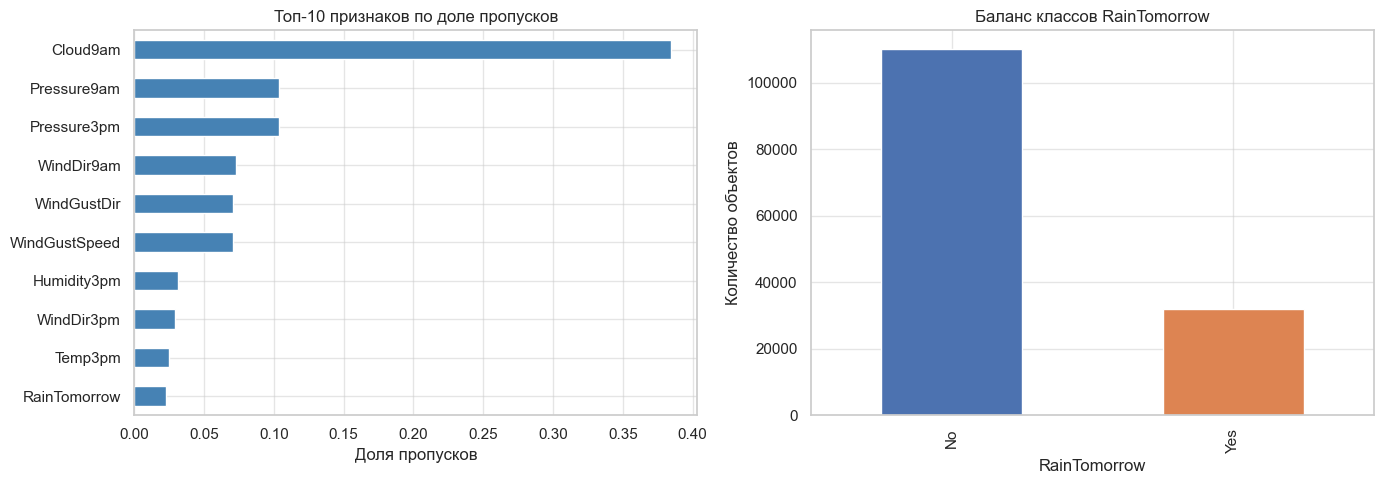

In [67]:
missing_share = weather_df.isna().mean().sort_values(ascending=False)
display(missing_share.head(15).to_frame("missing_share"))

class_distribution = weather_df["RainTomorrow"].value_counts(dropna=False)
display(class_distribution.to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_share.head(10).sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Топ-10 признаков по доле пропусков")
axes[0].set_xlabel("Доля пропусков")

class_distribution.drop(index=np.nan, errors="ignore").plot(kind="bar", ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_title("Баланс классов RainTomorrow")
axes[1].set_ylabel("Количество объектов")
plt.tight_layout()
plt.show()


## Вспомогательные функции

Ниже собраны общие функции для подготовки данных, запуска `GridSearchCV`, расчёта метрик, построения ROC/PR-кривых и извлечения важности признаков.


In [68]:
def make_preprocessor(numeric_cols: list[str], categorical_cols: list[str]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_cols),
            ("categorical", categorical_transformer, categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def prepare_catboost_frames(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    X_train_cb = X_train.copy()
    X_test_cb = X_test.copy()

    for col in numeric_cols:
        median_value = X_train_cb[col].median()
        X_train_cb[col] = X_train_cb[col].fillna(median_value)
        X_test_cb[col] = X_test_cb[col].fillna(median_value)

    for col in categorical_cols:
        mode_value = X_train_cb[col].mode(dropna=True).iloc[0]
        X_train_cb[col] = X_train_cb[col].fillna(mode_value).astype(str)
        X_test_cb[col] = X_test_cb[col].fillna(mode_value).astype(str)

    return X_train_cb, X_test_cb


def build_classifier_pipeline(
    model_name: str,
    numeric_cols: list[str],
    categorical_cols: list[str],
) -> Pipeline:
    preprocessor = make_preprocessor(numeric_cols, categorical_cols)

    if model_name == "AdaBoost":
        model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=SEED),
            random_state=SEED,
        )
    elif model_name == "GradientBoosting":
        model = GradientBoostingClassifier(random_state=SEED)
    elif model_name == "XGBoost":
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )
    else:
        raise ValueError(f"Unsupported classifier model: {model_name}")

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def build_classifier_grid(model_name: str) -> dict[str, list]:
    if model_name == "AdaBoost":
        return {
            "model__n_estimators": [120, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__estimator__max_depth": [1, 2],
            "model__estimator__ccp_alpha": [0.0, 0.001],
        }
    if model_name == "GradientBoosting":
        return {
            "model__n_estimators": [120, 180],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8, 1.0],
            "model__ccp_alpha": [0.0, 0.001],
        }
    if model_name == "XGBoost":
        return {
            "model__n_estimators": [150, 220],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [4, 6],
            "model__reg_alpha": [0.0, 0.2],
            "model__reg_lambda": [1.0, 3.0],
        }
    raise ValueError(f"Unsupported classifier model: {model_name}")


def build_catboost_classifier() -> CatBoostClassifier:
    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=SEED,
        allow_writing_files=False,
    )


def classifier_report_payload(
    estimator,
    X_train,
    X_test,
    y_train,
    y_test,
) -> dict:
    train_proba = estimator.predict_proba(X_train)[:, 1]
    test_proba = estimator.predict_proba(X_test)[:, 1]
    train_pred = (train_proba >= 0.5).astype(int)
    test_pred = (test_proba >= 0.5).astype(int)

    payload = {
        "summary": {
            "train_roc_auc": roc_auc_score(y_train, train_proba),
            "test_roc_auc": roc_auc_score(y_test, test_proba),
            "train_pr_auc": average_precision_score(y_train, train_proba),
            "test_pr_auc": average_precision_score(y_test, test_proba),
            "test_accuracy": accuracy_score(y_test, test_pred),
            "test_f1": f1_score(y_test, test_pred),
        },
        "y_train_proba": train_proba,
        "y_test_proba": test_proba,
        "y_test_pred": test_pred,
        "classification_report": pd.DataFrame(
            classification_report(y_test, test_pred, output_dict=True)
        ).T,
        "confusion_matrix": confusion_matrix(y_test, test_pred),
    }
    return payload


def plot_roc_pr_curves(
    results: dict,
    y_train: pd.Series,
    y_test: pd.Series,
    title_prefix: str,
) -> None:
    for model_name, payload in results.items():
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        fpr_train, tpr_train, _ = roc_curve(y_train, payload["metrics"]["y_train_proba"])
        fpr_test, tpr_test, _ = roc_curve(y_test, payload["metrics"]["y_test_proba"])
        axes[0].plot(fpr_train, tpr_train, label="train")
        axes[0].plot(fpr_test, tpr_test, label="test")
        axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
        axes[0].set_title(f"{title_prefix}: {model_name} / ROC")
        axes[0].set_xlabel("False Positive Rate")
        axes[0].set_ylabel("True Positive Rate")
        axes[0].legend()

        precision_train, recall_train, _ = precision_recall_curve(
            y_train, payload["metrics"]["y_train_proba"]
        )
        precision_test, recall_test, _ = precision_recall_curve(
            y_test, payload["metrics"]["y_test_proba"]
        )
        axes[1].plot(recall_train, precision_train, label="train")
        axes[1].plot(recall_test, precision_test, label="test")
        axes[1].set_title(f"{title_prefix}: {model_name} / Precision-Recall")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        axes[1].legend()

        plt.tight_layout()
        plt.show()


def get_tree_inputs_for_shap(
    model_name: str,
    fitted_estimator,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
):
    if model_name == "CatBoost":
        return X_train.copy(), X_test.copy(), fitted_estimator

    preprocessor = fitted_estimator.named_steps["preprocessor"]
    model = fitted_estimator.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()

    train_matrix = preprocessor.transform(X_train)
    test_matrix = preprocessor.transform(X_test)

    train_frame = pd.DataFrame(train_matrix, columns=feature_names, index=X_train.index)
    test_frame = pd.DataFrame(test_matrix, columns=feature_names, index=X_test.index)
    return train_frame, test_frame, model


def get_feature_importance_series(model_name: str, fitted_estimator) -> pd.Series:
    if model_name == "CatBoost":
        values = fitted_estimator.get_feature_importance()
        names = fitted_estimator.feature_names_
    else:
        preprocessor = fitted_estimator.named_steps["preprocessor"]
        model = fitted_estimator.named_steps["model"]
        values = model.feature_importances_
        names = preprocessor.get_feature_names_out()

    return pd.Series(values, index=names, dtype=float).sort_values(ascending=False)


def plot_importance_barh(importances: pd.Series, title: str, top_n: int = 15) -> None:
    top_values = importances.head(top_n).sort_values()
    plt.figure(figsize=(10, max(6, top_n * 0.35)))
    top_values.plot(kind="barh", color="#4c72b0")
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


def build_regression_pipeline(
    model_name: str,
    numeric_cols: list[str],
    categorical_cols: list[str],
) -> Pipeline:
    preprocessor = make_preprocessor(numeric_cols, categorical_cols)

    if model_name == "XGBoost":
        model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )
    else:
        raise ValueError(f"Unsupported regressor model: {model_name}")

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def build_regression_grid(model_name: str) -> dict[str, list]:
    if model_name == "XGBoost":
        return {
            "model__n_estimators": [180, 260],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [4, 6],
            "model__reg_alpha": [0.0, 0.2],
            "model__reg_lambda": [1.0, 3.0],
        }
    raise ValueError(f"Unsupported regressor model: {model_name}")


def build_catboost_regressor() -> CatBoostRegressor:
    return CatBoostRegressor(
        loss_function="RMSE",
        verbose=0,
        random_seed=SEED,
        allow_writing_files=False,
    )


def regression_report_payload(
    estimator,
    X_train,
    X_test,
    y_train,
    y_test,
) -> dict:
    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    return {
        "summary": {
            "train_rmse": np.sqrt(train_mse),
            "test_rmse": np.sqrt(test_mse),
            "test_mse": test_mse,
            "test_mae": mean_absolute_error(y_test, test_pred),
            "test_r2": r2_score(y_test, test_pred),
        },
        "y_test_pred": test_pred,
    }


## Классификация: подготовка данных

Для классификационной части:
- удаляем строки с неизвестным `RainTomorrow`
- используем стратифицированное разбиение
- компенсируем дисбаланс классов через `sample_weight`


In [69]:
classification_df = weather_df.dropna(subset=["RainTomorrow"]).copy()
classification_df["RainTomorrow"] = classification_df["RainTomorrow"].map({"No": 0, "Yes": 1})

X_cls = classification_df.drop(columns=["RainTomorrow"])
y_cls = classification_df["RainTomorrow"].astype(int)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_cls,
)

cls_numeric_cols = X_train_cls.select_dtypes(include=["number"]).columns.tolist()
cls_categorical_cols = X_train_cls.select_dtypes(exclude=["number"]).columns.tolist()
cls_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_cls)

X_train_cls_cb, X_test_cls_cb = prepare_catboost_frames(
    X_train_cls,
    X_test_cls,
    cls_numeric_cols,
    cls_categorical_cols,
)

print("Classification train shape:", X_train_cls.shape)
print("Classification test shape:", X_test_cls.shape)
print("Numeric features:", cls_numeric_cols)
print("Categorical features:", cls_categorical_cols)
print("Positive class share in train:", y_train_cls.mean().round(4))


Classification train shape: (113754, 23)
Classification test shape: (28439, 23)
Numeric features: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'Year', 'DayOfYear']
Categorical features: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month', 'Season', 'IsMonthStart']
Positive class share in train: 0.2242


## Классификация: `GridSearchCV` для `AdaBoost`, `GradientBoostingClassifier`, `XGBoost`, `CatBoost`

В качестве основной метрики отбора используется `ROC AUC`.  
Для `AdaBoost`, `GradientBoostingClassifier` и `XGBoost` категориальные признаки кодируются `OrdinalEncoder` с `handle_unknown="use_encoded_value"` и `unknown_value=-1`.  
Для `CatBoost` кодирование не применяется: категориальные признаки передаются нативно через параметр `cat_features`.

В сетках перебираются число деревьев, скорость обучения и глубина. Для `XGBoost` используются явные параметры регуляризации `reg_alpha` и `reg_lambda`, для `CatBoost` — `l2_leaf_reg`. Для моделей из `sklearn` регуляризация задаётся через ограничение глубины базовых деревьев и, где доступно, параметры структуры ансамбля.

In [70]:
classification_results = {}

for model_name in ["AdaBoost", "GradientBoosting", "XGBoost"]:
    pipeline = build_classifier_pipeline(model_name, cls_numeric_cols, cls_categorical_cols)
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=build_classifier_grid(model_name),
        scoring="roc_auc",
        cv=CLASSIFICATION_CV,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    search.fit(X_train_cls, y_train_cls, model__sample_weight=cls_sample_weight)
    metrics = classifier_report_payload(
        search.best_estimator_,
        X_train_cls,
        X_test_cls,
        y_train_cls,
        y_test_cls,
    )
    classification_results[model_name] = {
        "search": search,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "metrics": metrics,
    }

catboost_cls_search = GridSearchCV(
    estimator=build_catboost_classifier(),
    param_grid={
        "iterations": [160, 240],
        "learning_rate": [0.05, 0.1],
        "depth": [4, 6],
        "l2_leaf_reg": [3.0, 6.0],
    },
    scoring="roc_auc",
    cv=CLASSIFICATION_CV,
    n_jobs=1,
    verbose=1,
    refit=True,
)
catboost_cls_search.fit(
    X_train_cls_cb,
    y_train_cls,
    cat_features=cls_categorical_cols,
    sample_weight=cls_sample_weight,
)
catboost_cls_metrics = classifier_report_payload(
    catboost_cls_search.best_estimator_,
    X_train_cls_cb,
    X_test_cls_cb,
    y_train_cls,
    y_test_cls,
)
classification_results["CatBoost"] = {
    "search": catboost_cls_search,
    "best_estimator": catboost_cls_search.best_estimator_,
    "best_params": catboost_cls_search.best_params_,
    "metrics": catboost_cls_metrics,
}


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits


In [71]:
classification_summary = (
    pd.DataFrame(
        {
            model_name: payload["metrics"]["summary"]
            for model_name, payload in classification_results.items()
        }
    )
    .T
    .sort_values(["test_roc_auc", "test_pr_auc", "test_f1"], ascending=False)
)

classification_best_params = pd.DataFrame(
    {
        model_name: payload["best_params"]
        for model_name, payload in classification_results.items()
    }
).T

display(classification_summary)
display(classification_best_params)

best_cls_name = classification_summary.index[0]
best_cls_payload = classification_results[best_cls_name]
print(f"Best classifier by ROC AUC: {best_cls_name}")
display(best_cls_payload["metrics"]["classification_report"])
print("Confusion matrix:")
print(best_cls_payload["metrics"]["confusion_matrix"])


,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc,test_accuracy,test_f1
CatBoost,0.904145,0.893512,0.767612,0.751830,0.815605,0.659215
XGBoost,0.924192,0.892463,0.809008,0.750220,0.819262,0.660995
GradientBoosting,0.879230,0.875723,0.723225,0.720580,0.799325,0.633674
AdaBoost,0.854715,0.856979,0.681160,0.688867,0.783537,0.610872


,model__estimator__ccp_alpha,model__estimator__max_depth,model__learning_rate,model__n_estimators,model__ccp_alpha,model__max_depth,model__subsample,model__reg_alpha,model__reg_lambda,depth,iterations,l2_leaf_reg,learning_rate
AdaBoost,0.001,2.0,0.1,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GradientBoosting,NaN,NaN,0.1,180.0,0.0,3.0,0.8,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,NaN,NaN,0.1,220.0,NaN,6.0,NaN,0.2,3.0,NaN,NaN,NaN,NaN
CatBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,240.0,3.0,0.1


Best classifier by ROC AUC: CatBoost


,precision,recall,f1-score,support
0,0.932925,0.821383,0.873608,22064.000000
1,0.562743,0.795608,0.659215,6375.000000
accuracy,0.815605,0.815605,0.815605,0.815605
macro avg,0.747834,0.808496,0.766412,28439.000000
weighted avg,0.849943,0.815605,0.825549,28439.000000


Confusion matrix:
[[18123  3941]
 [ 1303  5072]]


## Вывод по классификации

По метрике `ROC AUC` лучшей моделью стала `CatBoost`. У неё самый высокий `test_roc_auc`, при этом `XGBoost` даёт очень близкое качество и немного выше `F1`. Для дальнейшего анализа выбран `CatBoost`, потому что основным критерием отбора в работе был `ROC AUC`, а эта метрика лучше отражает качество ранжирования при несбалансированных классах.

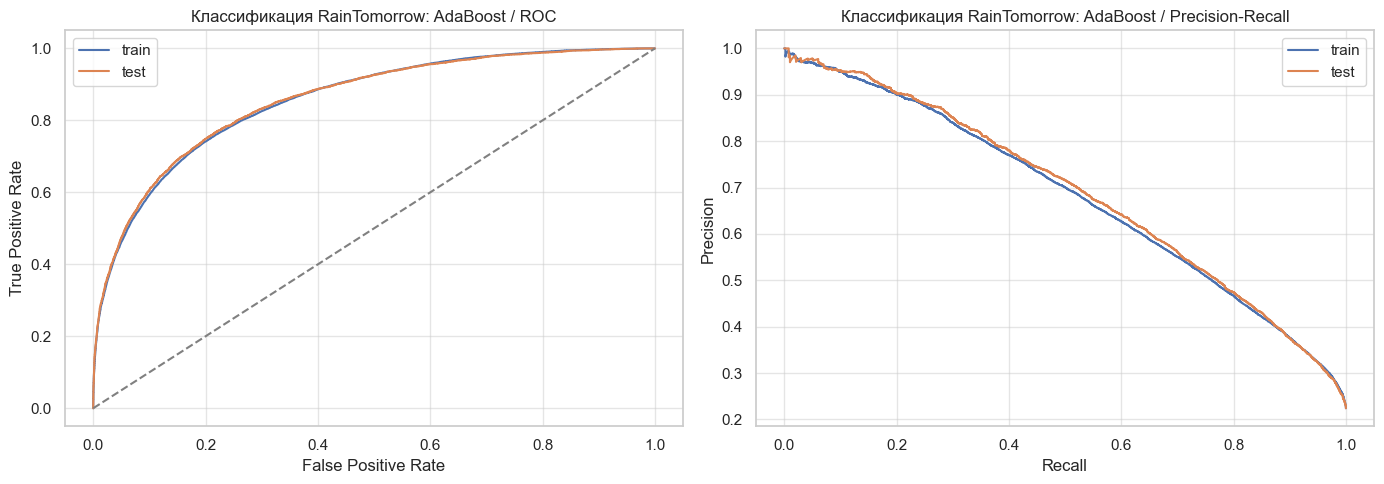

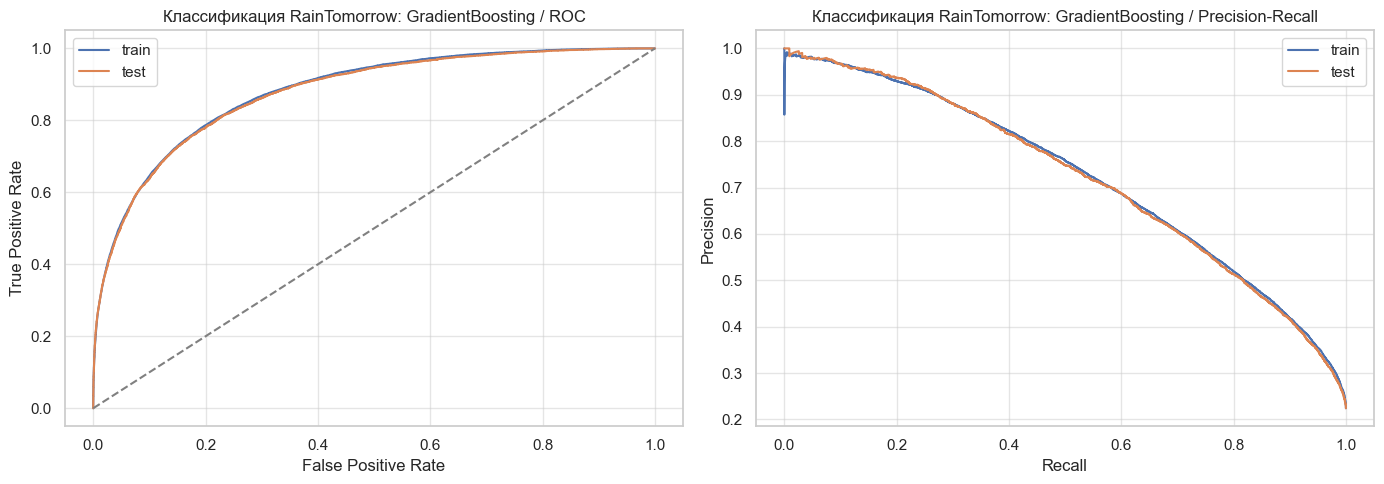

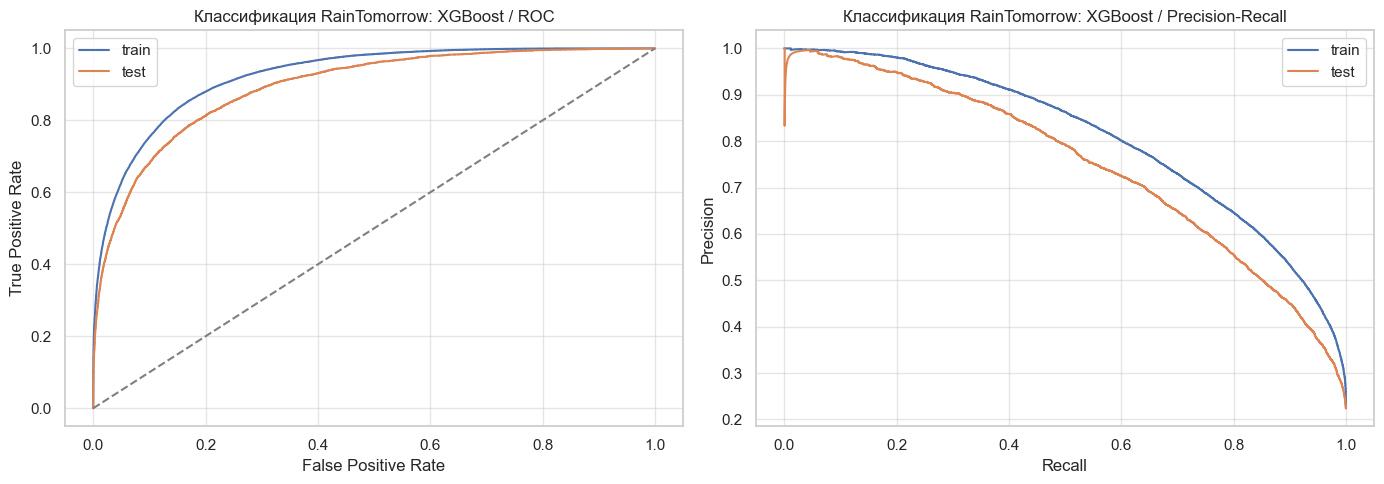

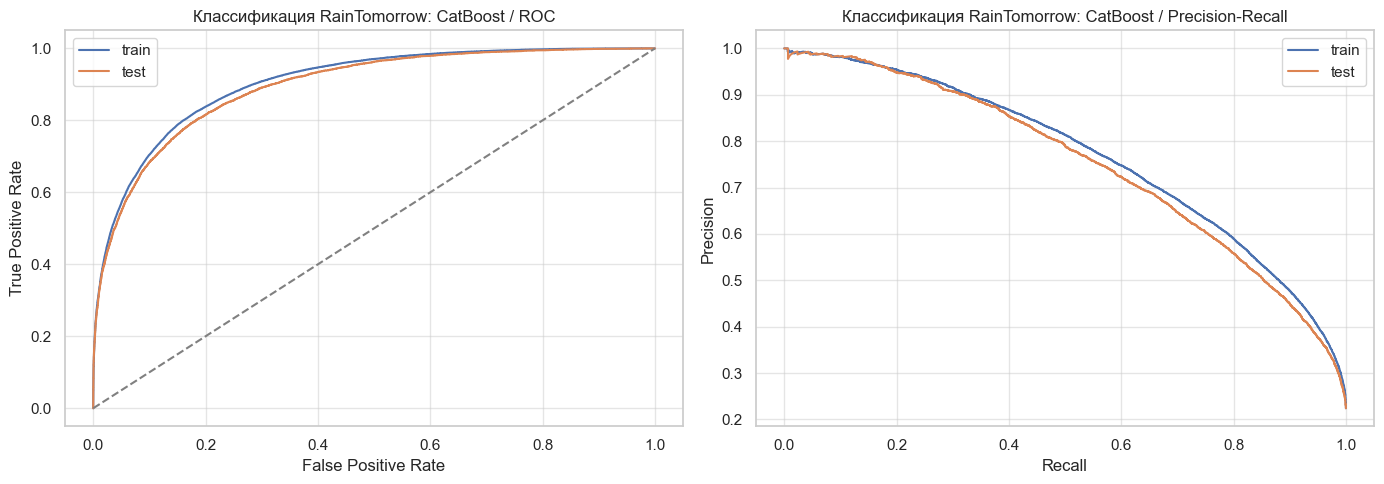

In [72]:
plot_roc_pr_curves(
    classification_results,
    y_train_cls,
    y_test_cls,
    title_prefix="Классификация RainTomorrow",
)


## Классификация: `SHAP`-анализ лучшей модели и фильтрация признаков

Используем `shap.TreeExplainer`, после чего:
- строим локальные и глобальные графики важности
- выбираем наиболее значимые признаки
- переобучаем лучшую модель на сокращённом наборе
- сравниваем метрики до и после фильтрации


In [73]:
if best_cls_name == "CatBoost":
    shap_train_source, shap_test_source, shap_model = get_tree_inputs_for_shap(
        best_cls_name,
        best_cls_payload["best_estimator"],
        X_train_cls_cb,
        X_test_cls_cb,
    )
else:
    shap_train_source, shap_test_source, shap_model = get_tree_inputs_for_shap(
        best_cls_name,
        best_cls_payload["best_estimator"],
        X_train_cls,
        X_test_cls,
    )

shap_train_sample = shap_train_source.sample(
    n=min(SHAP_SAMPLE_SIZE, len(shap_train_source)),
    random_state=SEED,
)
shap_test_sample = shap_test_source.sample(
    n=min(SHAP_SAMPLE_SIZE, len(shap_test_source)),
    random_state=SEED,
)

cls_explainer = shap.TreeExplainer(shap_model)
cls_shap_values = cls_explainer(shap_test_sample)

cls_shap_importance = (
    pd.Series(
        np.abs(cls_shap_values.values).mean(axis=0),
        index=shap_test_sample.columns,
    )
    .sort_values(ascending=False)
)
selected_cls_features = cls_shap_importance.head(12).index.tolist()

print("Selected classification features after SHAP filtering:")
print(selected_cls_features)
display(cls_shap_importance.head(15).to_frame("mean_abs_shap"))


Selected classification features after SHAP filtering:
['Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'Location', 'Cloud9am', 'WindDir3pm', 'Rainfall', 'Humidity9am', 'MaxTemp', 'DayOfYear', 'WindGustDir', 'Pressure9am']


,mean_abs_shap
Humidity3pm,0.844161
Pressure3pm,0.462198
WindGustSpeed,0.432196
Location,0.236972
Cloud9am,0.186875
WindDir3pm,0.181691
Rainfall,0.126312
Humidity9am,0.105994
MaxTemp,0.105159
DayOfYear,0.093175


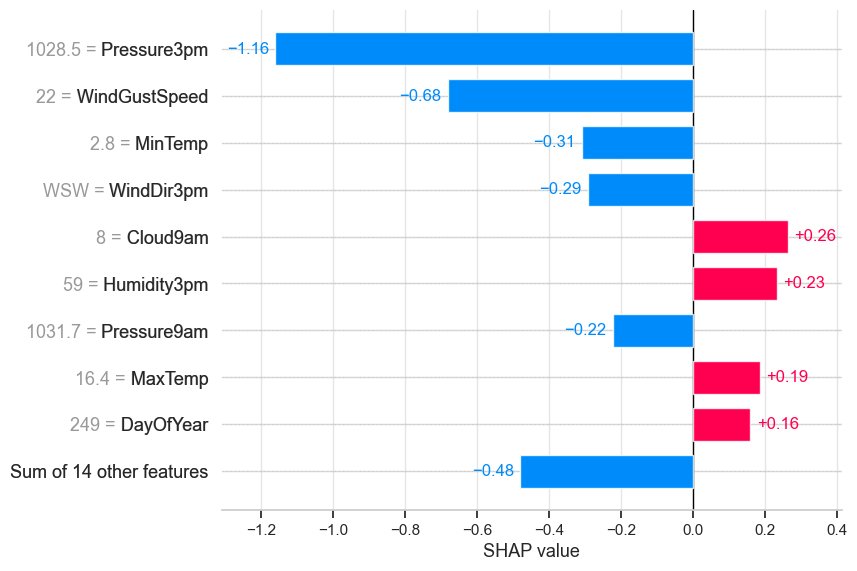

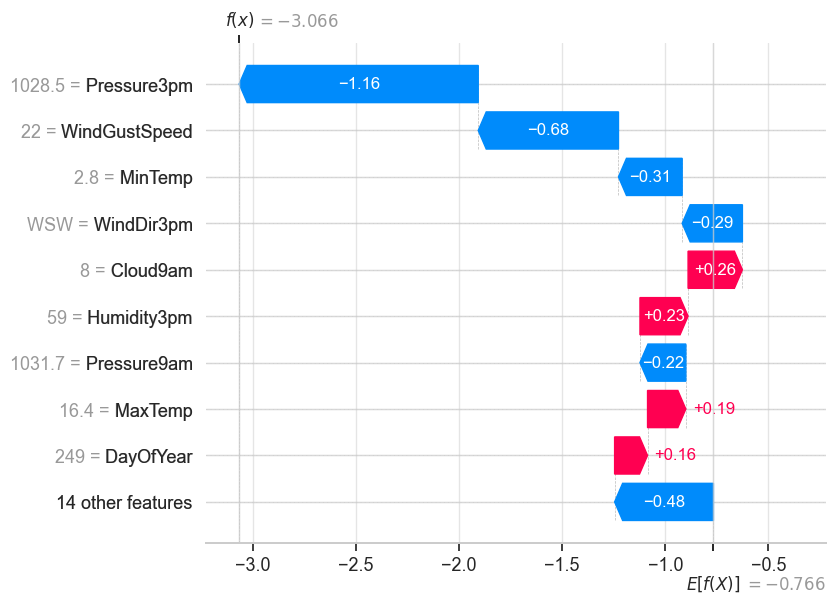

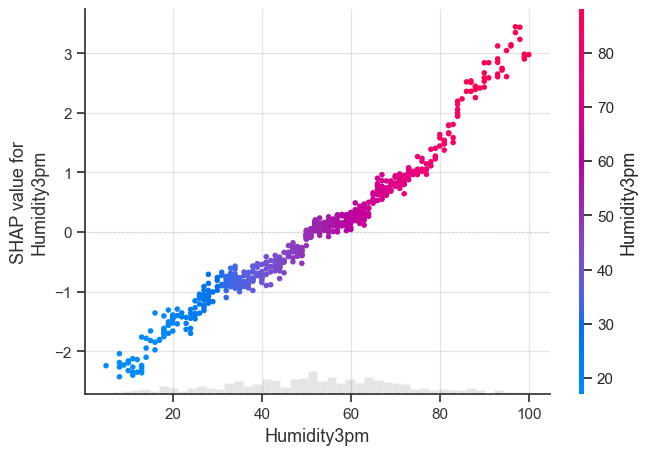

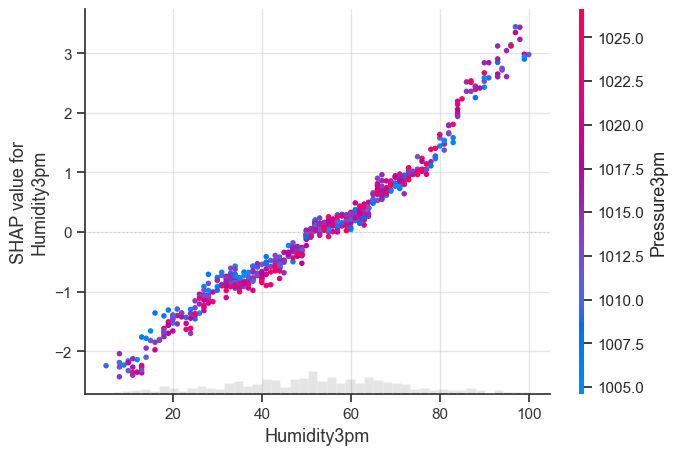

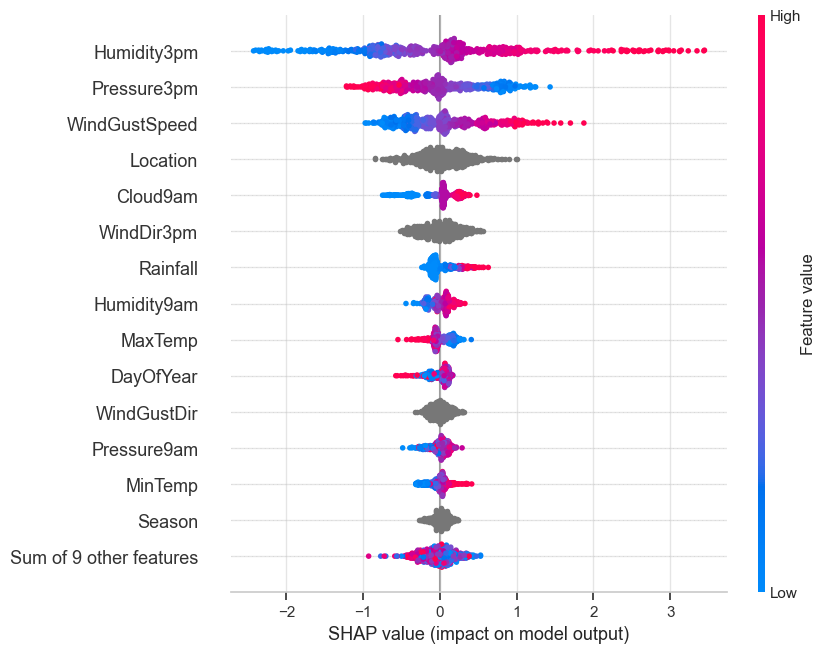

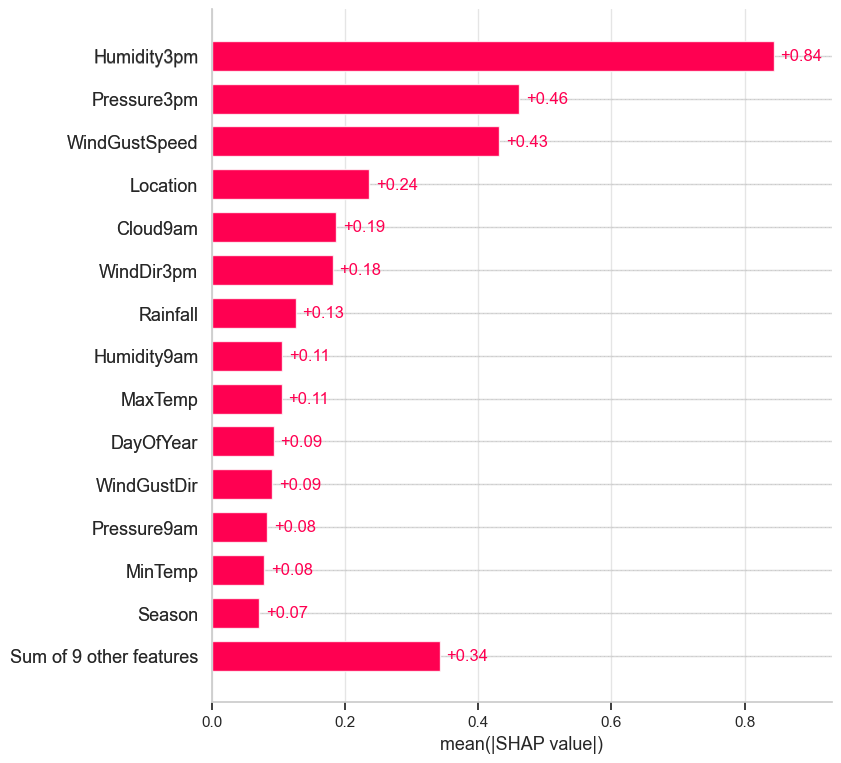

In [74]:
shap.plots.force(cls_shap_values[0])
shap.plots.force(cls_shap_values[:50])
shap.plots.bar(cls_shap_values[0])
shap.plots.waterfall(cls_shap_values[0])

top_feature = cls_shap_importance.index[0]
second_feature = cls_shap_importance.index[1]
shap.plots.scatter(cls_shap_values[:, top_feature], color=cls_shap_values[:, top_feature])
shap.plots.scatter(cls_shap_values[:, top_feature], color=cls_shap_values[:, second_feature])
shap.plots.beeswarm(cls_shap_values, max_display=15)
shap.plots.bar(cls_shap_values, max_display=15)


In [75]:
cls_selected_numeric = [col for col in selected_cls_features if col in cls_numeric_cols]
cls_selected_categorical = [col for col in selected_cls_features if col in cls_categorical_cols]

if best_cls_name == "CatBoost":
    filtered_cls_model = build_catboost_classifier()
    filtered_cls_model.set_params(**best_cls_payload["best_params"])
    filtered_X_train_cls = X_train_cls_cb[selected_cls_features].copy()
    filtered_X_test_cls = X_test_cls_cb[selected_cls_features].copy()
    filtered_cls_model.fit(
        filtered_X_train_cls,
        y_train_cls,
        cat_features=cls_selected_categorical,
        sample_weight=cls_sample_weight,
    )
    filtered_cls_metrics = classifier_report_payload(
        filtered_cls_model,
        filtered_X_train_cls,
        filtered_X_test_cls,
        y_train_cls,
        y_test_cls,
    )
else:
    filtered_cls_model = build_classifier_pipeline(
        best_cls_name,
        cls_selected_numeric,
        cls_selected_categorical,
    )
    filtered_cls_model.set_params(**best_cls_payload["best_params"])
    filtered_cls_model.fit(
        X_train_cls[selected_cls_features],
        y_train_cls,
        model__sample_weight=cls_sample_weight,
    )
    filtered_cls_metrics = classifier_report_payload(
        filtered_cls_model,
        X_train_cls[selected_cls_features],
        X_test_cls[selected_cls_features],
        y_train_cls,
        y_test_cls,
    )

classification_comparison = pd.DataFrame(
    [best_cls_payload["metrics"]["summary"], filtered_cls_metrics["summary"]],
    index=["before_filtering", "after_filtering"],
)

display(classification_comparison)
display(filtered_cls_metrics["classification_report"])
print("Confusion matrix after filtering:")
print(filtered_cls_metrics["confusion_matrix"])


,train_roc_auc,test_roc_auc,train_pr_auc,test_pr_auc,test_accuracy,test_f1
before_filtering,0.904145,0.893512,0.767612,0.751830,0.815605,0.659215
after_filtering,0.900227,0.891816,0.760761,0.748411,0.814058,0.656891


,precision,recall,f1-score,support
0,0.932327,0.819842,0.872474,22064.000000
1,0.560142,0.794039,0.656891,6375.000000
accuracy,0.814058,0.814058,0.814058,0.814058
macro avg,0.746234,0.806941,0.764682,28439.000000
weighted avg,0.848896,0.814058,0.824148,28439.000000


Confusion matrix after filtering:
[[18089  3975]
 [ 1313  5062]]


## Вывод по фильтрации признаков в классификации

После отбора наиболее важных признаков качество изменилось незначительно. Небольшое снижение `ROC AUC`, `PR AUC` и `F1` показывает, что удалённые признаки всё же содержали часть полезной информации, но сокращённая модель остаётся близкой по качеству и проще для интерпретации.

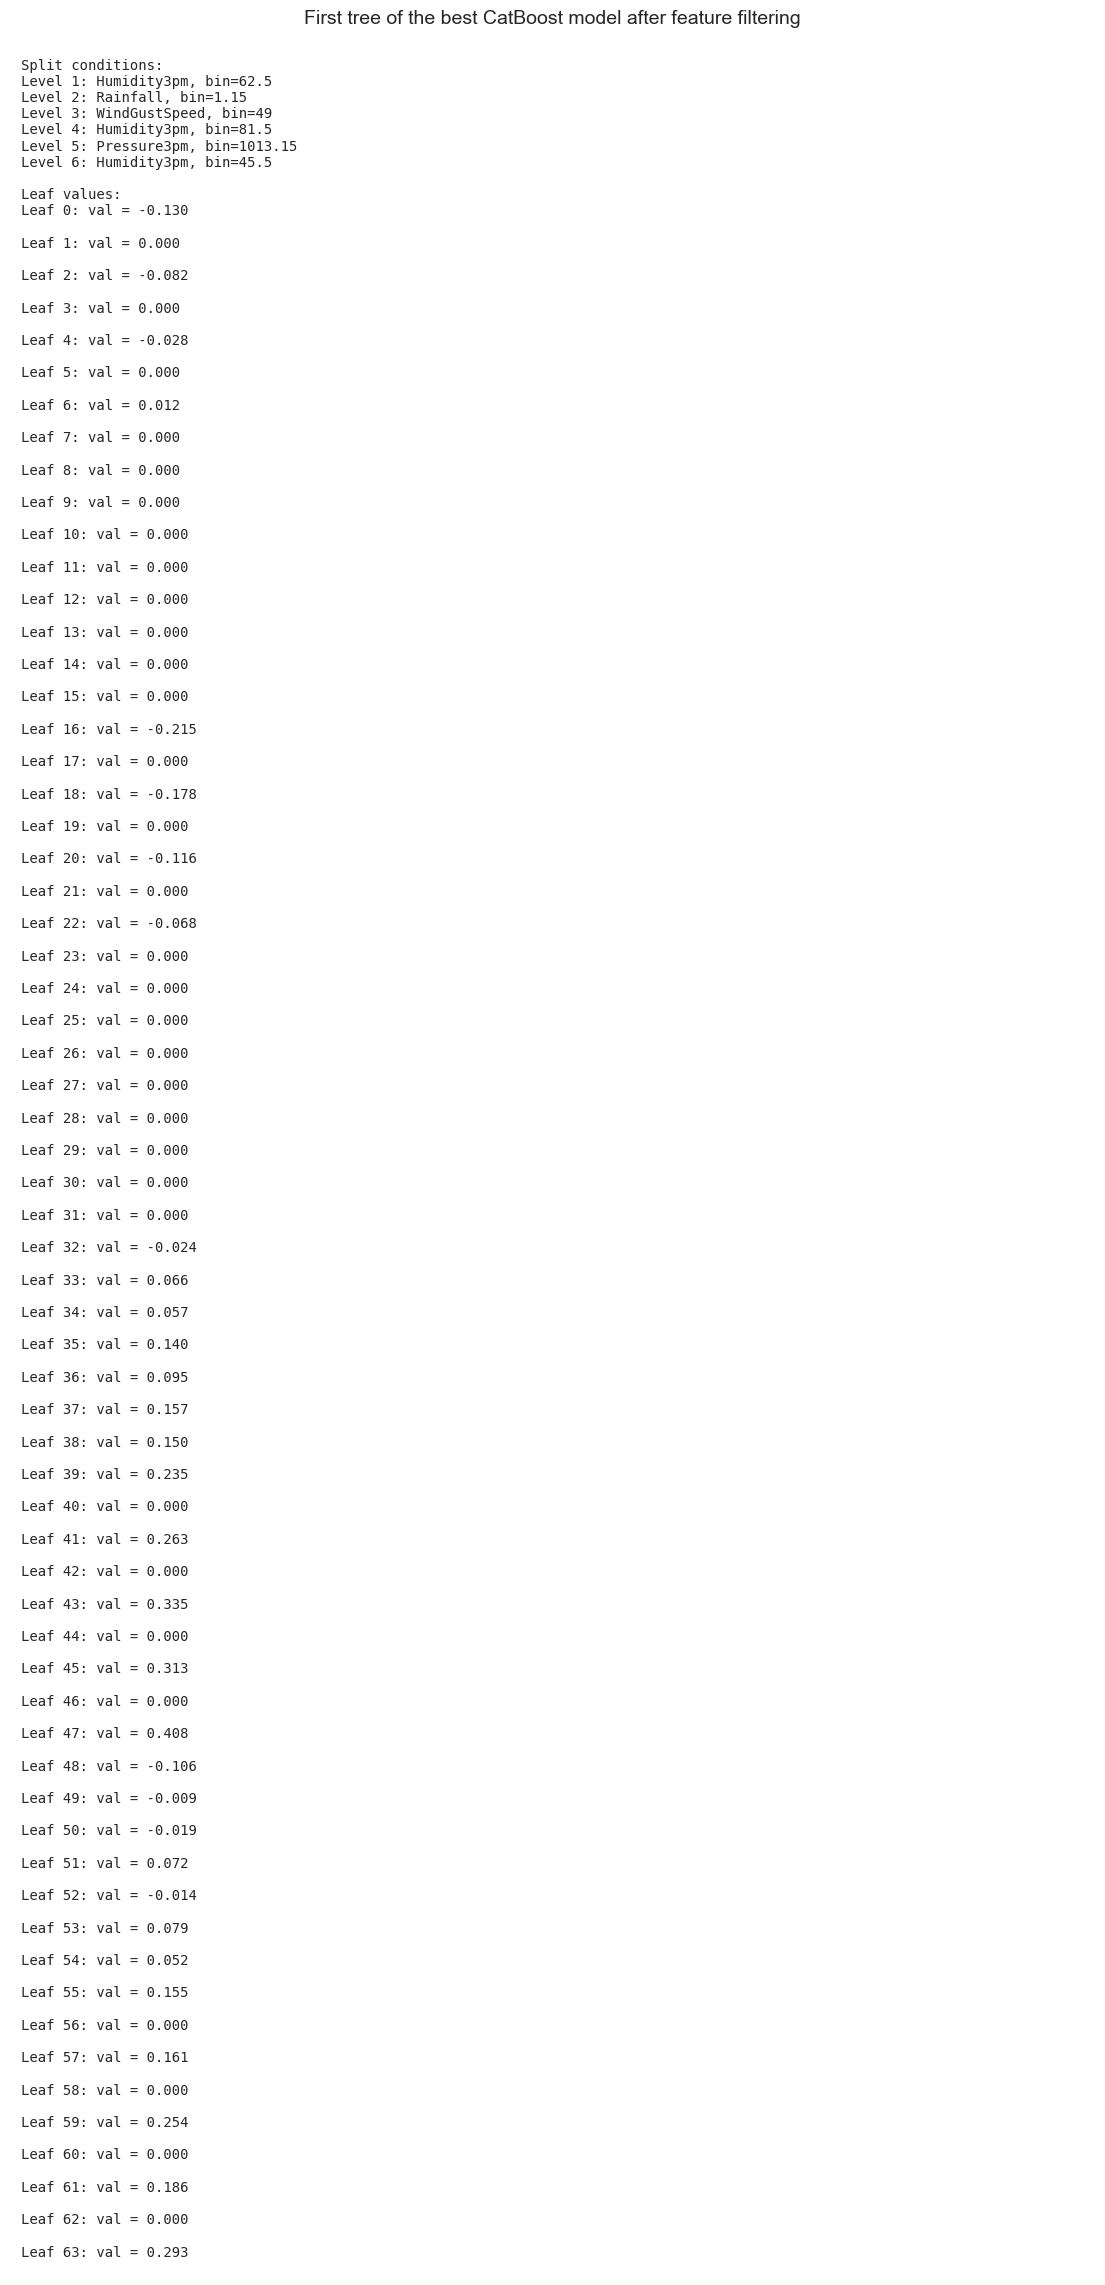

In [76]:
plt.figure(figsize=(20, 8))

if best_cls_name == "XGBoost":
    xgb_plot_tree(filtered_cls_model.named_steps["model"], num_trees=0)
    plt.title("First tree of the best XGBoost model after feature filtering")
elif best_cls_name == "GradientBoosting":
    plot_tree(
        filtered_cls_model.named_steps["model"].estimators_[0, 0],
        filled=True,
        rounded=True,
        feature_names=selected_cls_features,
        max_depth=3,
    )
    plt.title("First tree of the best GradientBoosting model after feature filtering")
elif best_cls_name == "AdaBoost":
    plot_tree(
        filtered_cls_model.named_steps["model"].estimators_[0],
        filled=True,
        rounded=True,
        feature_names=selected_cls_features,
        max_depth=3,
    )
    plt.title("First tree of the best AdaBoost model after feature filtering")
else:
    plt.close()
    catboost_pool = Pool(
        filtered_X_train_cls,
        label=y_train_cls,
        cat_features=cls_selected_categorical,
    )
    tree_splits = filtered_cls_model._get_tree_splits(tree_idx=0, pool=catboost_pool)
    tree_leaf_values = filtered_cls_model._get_tree_leaf_values(tree_idx=0)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis("off")
    ax.set_title("First tree of the best CatBoost model after feature filtering", fontsize=14, pad=16)

    split_lines = [f"Level {i + 1}: {split}" for i, split in enumerate(tree_splits)]
    leaf_lines = [f"Leaf {i}: {value}" for i, value in enumerate(tree_leaf_values)]
    tree_text = "Split conditions:\n" + "\n".join(split_lines)
    tree_text += "\n\nLeaf values:\n" + "\n".join(leaf_lines)

    ax.text(
        0.01,
        0.98,
        tree_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=10,
        transform=ax.transAxes,
    )
    plt.tight_layout()
    plt.show()

if best_cls_name != "CatBoost":
    plt.tight_layout()
    plt.show()


## Регрессия: подготовка данных

В регрессионной части прогнозируем `MaxTemp`.  
Колонка `RainTomorrow` удаляется из признаков, чтобы не использовать информацию из будущего дня.


In [77]:
regression_df = weather_df.dropna(subset=["MaxTemp"]).copy()

X_reg = regression_df.drop(columns=["MaxTemp", "RainTomorrow"])
y_reg = regression_df["MaxTemp"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=TEST_SIZE,
    random_state=SEED,
)

reg_numeric_cols = X_train_reg.select_dtypes(include=["number"]).columns.tolist()
reg_categorical_cols = X_train_reg.select_dtypes(exclude=["number"]).columns.tolist()

X_train_reg_cb, X_test_reg_cb = prepare_catboost_frames(
    X_train_reg,
    X_test_reg,
    reg_numeric_cols,
    reg_categorical_cols,
)

print("Regression train shape:", X_train_reg.shape)
print("Regression test shape:", X_test_reg.shape)
print("Numeric features:", reg_numeric_cols)
print("Categorical features:", reg_categorical_cols)


Regression train shape: (115359, 22)
Regression test shape: (28840, 22)
Numeric features: ['MinTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'Year', 'DayOfYear']
Categorical features: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month', 'Season', 'IsMonthStart']


## Регрессия: `XGBRegressor` и `CatBoostRegressor`

Для отбора гиперпараметров используется `GridSearchCV`, а на тестовой выборке выводятся `MSE`, `MAE` и `R^2`.


In [78]:
regression_results = {}

xgb_reg_search = GridSearchCV(
    estimator=build_regression_pipeline("XGBoost", reg_numeric_cols, reg_categorical_cols),
    param_grid=build_regression_grid("XGBoost"),
    scoring="neg_root_mean_squared_error",
    cv=REGRESSION_CV,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
xgb_reg_search.fit(X_train_reg, y_train_reg)
regression_results["XGBoost"] = {
    "search": xgb_reg_search,
    "best_estimator": xgb_reg_search.best_estimator_,
    "best_params": xgb_reg_search.best_params_,
    "metrics": regression_report_payload(
        xgb_reg_search.best_estimator_,
        X_train_reg,
        X_test_reg,
        y_train_reg,
        y_test_reg,
    ),
}

catboost_reg_search = GridSearchCV(
    estimator=build_catboost_regressor(),
    param_grid={
        "iterations": [180, 260],
        "learning_rate": [0.05, 0.1],
        "depth": [4, 6],
        "l2_leaf_reg": [3.0, 6.0],
    },
    scoring="neg_root_mean_squared_error",
    cv=REGRESSION_CV,
    n_jobs=1,
    verbose=1,
    refit=True,
)
catboost_reg_search.fit(
    X_train_reg_cb,
    y_train_reg,
    cat_features=reg_categorical_cols,
)
regression_results["CatBoost"] = {
    "search": catboost_reg_search,
    "best_estimator": catboost_reg_search.best_estimator_,
    "best_params": catboost_reg_search.best_params_,
    "metrics": regression_report_payload(
        catboost_reg_search.best_estimator_,
        X_train_reg_cb,
        X_test_reg_cb,
        y_train_reg,
        y_test_reg,
    ),
}


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Fitting 3 folds for each of 16 candidates, totalling 48 fits


In [79]:
regression_summary = (
    pd.DataFrame(
        {
            model_name: payload["metrics"]["summary"]
            for model_name, payload in regression_results.items()
        }
    )
    .T
    .sort_values(["test_rmse", "test_mae"], ascending=True)
)

regression_best_params = pd.DataFrame(
    {
        model_name: payload["best_params"]
        for model_name, payload in regression_results.items()
    }
).T

display(regression_summary)
display(regression_best_params)

best_reg_name = regression_summary.index[0]
best_reg_payload = regression_results[best_reg_name]
print(f"Best regressor by RMSE: {best_reg_name}")


,train_rmse,test_rmse,test_mse,test_mae,test_r2
XGBoost,0.828355,0.918553,0.843739,0.625647,0.983424
CatBoost,0.919007,0.937978,0.879803,0.650803,0.982715


,model__learning_rate,model__max_depth,model__n_estimators,model__reg_alpha,model__reg_lambda,depth,iterations,l2_leaf_reg,learning_rate
XGBoost,0.1,6.0,260.0,0.0,3.0,NaN,NaN,NaN,NaN
CatBoost,NaN,NaN,NaN,NaN,NaN,6.0,260.0,3.0,0.1


Best regressor by RMSE: XGBoost


## Регрессия: важность признаков, фильтрация и повторное обучение

По аналогии с классификационной частью:
- извлекаем важности признаков лучшего регрессора
- оставляем наиболее значимые признаки
- переобучаем лучшую модель
- сравниваем метрики до и после фильтрации


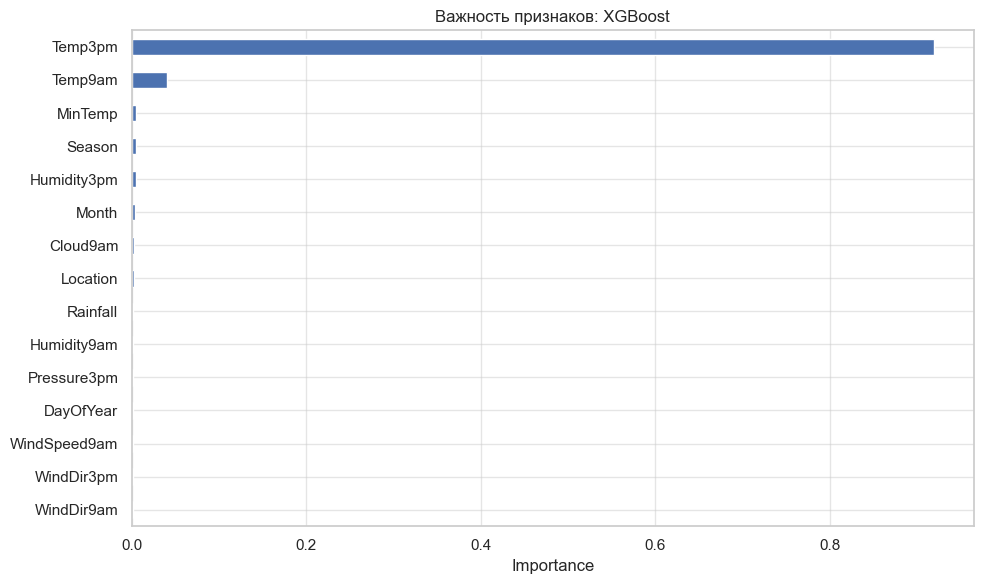

Selected regression features after filtering:
['Temp3pm', 'Temp9am', 'MinTemp', 'Season', 'Humidity3pm', 'Month', 'Cloud9am', 'Location', 'Rainfall', 'Humidity9am', 'Pressure3pm', 'DayOfYear']


In [80]:
reg_importances = get_feature_importance_series(best_reg_name, best_reg_payload["best_estimator"])
selected_reg_features = reg_importances.head(12).index.tolist()

plot_importance_barh(reg_importances, title=f"Важность признаков: {best_reg_name}", top_n=15)

print("Selected regression features after filtering:")
print(selected_reg_features)


,train_rmse,test_rmse,test_mse,test_mae,test_r2
before_filtering,0.828355,0.918553,0.843739,0.625647,0.983424
after_filtering,0.856278,0.943672,0.890516,0.642391,0.982505


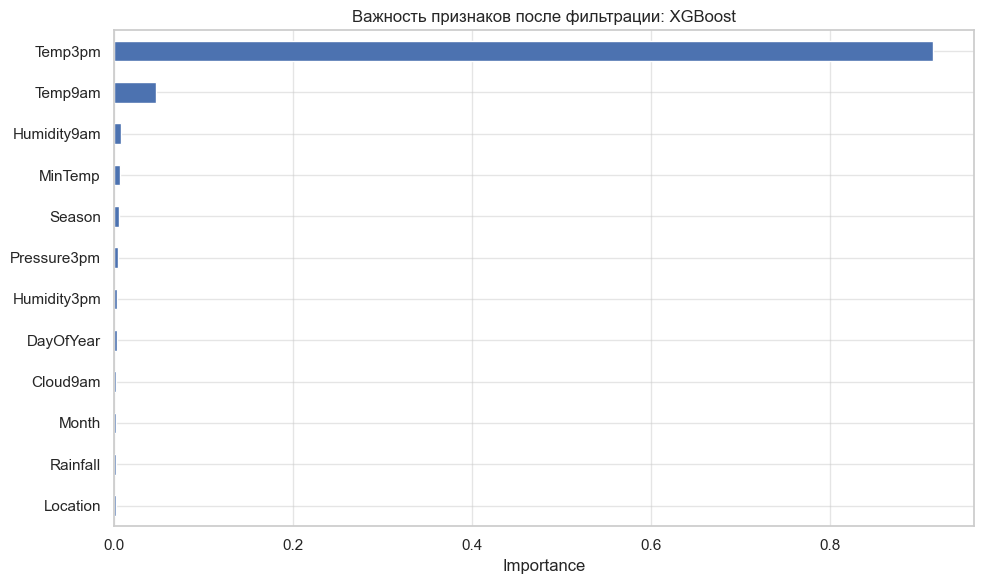

In [81]:
reg_selected_numeric = [col for col in selected_reg_features if col in reg_numeric_cols]
reg_selected_categorical = [col for col in selected_reg_features if col in reg_categorical_cols]

if best_reg_name == "CatBoost":
    filtered_reg_model = build_catboost_regressor()
    filtered_reg_model.set_params(**best_reg_payload["best_params"])
    filtered_X_train_reg = X_train_reg_cb[selected_reg_features].copy()
    filtered_X_test_reg = X_test_reg_cb[selected_reg_features].copy()
    filtered_reg_model.fit(
        filtered_X_train_reg,
        y_train_reg,
        cat_features=reg_selected_categorical,
    )
    filtered_reg_metrics = regression_report_payload(
        filtered_reg_model,
        filtered_X_train_reg,
        filtered_X_test_reg,
        y_train_reg,
        y_test_reg,
    )
else:
    filtered_reg_model = build_regression_pipeline(
        best_reg_name,
        reg_selected_numeric,
        reg_selected_categorical,
    )
    filtered_reg_model.set_params(**best_reg_payload["best_params"])
    filtered_reg_model.fit(
        X_train_reg[selected_reg_features],
        y_train_reg,
    )
    filtered_reg_metrics = regression_report_payload(
        filtered_reg_model,
        X_train_reg[selected_reg_features],
        X_test_reg[selected_reg_features],
        y_train_reg,
        y_test_reg,
    )

regression_comparison = pd.DataFrame(
    [best_reg_payload["metrics"]["summary"], filtered_reg_metrics["summary"]],
    index=["before_filtering", "after_filtering"],
)

display(regression_comparison)

if best_reg_name == "CatBoost":
    filtered_reg_importances = pd.Series(
        filtered_reg_model.get_feature_importance(),
        index=selected_reg_features,
        dtype=float,
    ).sort_values(ascending=False)
else:
    filtered_reg_importances = pd.Series(
        filtered_reg_model.named_steps["model"].feature_importances_,
        index=selected_reg_features,
        dtype=float,
    ).sort_values(ascending=False)

plot_importance_barh(
    filtered_reg_importances,
    title=f"Важность признаков после фильтрации: {best_reg_name}",
    top_n=min(12, len(filtered_reg_importances)),
)


## Итоговые выводы

В последней ячейке выводятся краткие выводы по классификации и регрессии: какая модель оказалась лучшей, как изменились метрики после фильтрации признаков и насколько оправдано сокращение набора признаков.

In [82]:
cls_before = classification_comparison.loc["before_filtering"]
cls_after = classification_comparison.loc["after_filtering"]
reg_before = regression_comparison.loc["before_filtering"]
reg_after = regression_comparison.loc["after_filtering"]

print("Классификация")
print(
    f"Лучшей моделью по ROC AUC стала {best_cls_name}: "
    f"ROC AUC на тесте = {cls_before['test_roc_auc']:.4f}, "
    f"PR AUC = {cls_before['test_pr_auc']:.4f}, "
    f"F1 = {cls_before['test_f1']:.4f}."
)
print(
    f"После фильтрации признаков: ROC AUC = {cls_after['test_roc_auc']:.4f}, "
    f"PR AUC = {cls_after['test_pr_auc']:.4f}, "
    f"F1 = {cls_after['test_f1']:.4f}."
)
if cls_after["test_roc_auc"] >= cls_before["test_roc_auc"]:
    print("Фильтрация сохранила качество классификации и сократила набор признаков.")
else:
    print("После фильтрации качество классификации немного снизилось, зато модель стала компактнее.")

print("\nРегрессия")
print(
    f"Лучшей моделью по RMSE стала {best_reg_name}: "
    f"RMSE на тесте = {reg_before['test_rmse']:.4f}, "
    f"MSE = {reg_before['test_mse']:.4f}, "
    f"MAE = {reg_before['test_mae']:.4f}, "
    f"R2 = {reg_before['test_r2']:.4f}."
)
print(
    f"После фильтрации признаков: RMSE = {reg_after['test_rmse']:.4f}, "
    f"MSE = {reg_after['test_mse']:.4f}, "
    f"MAE = {reg_after['test_mae']:.4f}, "
    f"R2 = {reg_after['test_r2']:.4f}."
)
if reg_after["test_rmse"] <= reg_before["test_rmse"]:
    print("Фильтрация признаков для регрессии оказалась полезной или нейтральной по RMSE.")
else:
    print("После фильтрации RMSE вырос, значит часть удалённых признаков была полезна для прогноза.")

Классификация
Лучшей моделью по ROC AUC стала CatBoost: ROC AUC на тесте = 0.8935, PR AUC = 0.7518, F1 = 0.6592.
После фильтрации признаков: ROC AUC = 0.8918, PR AUC = 0.7484, F1 = 0.6569.
После фильтрации качество классификации немного снизилось, зато модель стала компактнее.

Регрессия
Лучшей моделью по RMSE стала XGBoost: RMSE на тесте = 0.9186, MSE = 0.8437, MAE = 0.6256, R2 = 0.9834.
После фильтрации признаков: RMSE = 0.9437, MSE = 0.8905, MAE = 0.6424, R2 = 0.9825.
После фильтрации RMSE вырос, значит часть удалённых признаков была полезна для прогноза.
